# gBEC from All Optimal Demonstrations — Two Gridworld MDPs

Reproduces Figure 4 of the paper:  
> *Two gridworld MDPs share the same reward features but differ in layout.*  
> *The feasible reward region in MDP 2 is strictly larger than in MDP 1.*

**Approach (exact, no sampling):**
1. Run Value Iteration to get Q*(s,a) for both MDPs.
2. Compute action-successor features ψ(s,a) = expected discounted feature vector when  
   taking action *a* at state *s* then following the optimal policy.
3. For every non-terminal state *s*, every optimal action *a** ∈ argmax Q*(s,·),  
   and every non-optimal action *b*: add constraint **(ψ(s,a*) − ψ(s,b)) · w ≥ 0**.
4. Remove redundant constraints via LP.
5. Plot the feasible reward half-space intersection.

In [1]:
import io
import os
import sys
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Project root on sys.path (works from data_generation/, appendix/, or repo root) ──
_here = os.path.abspath(os.getcwd())
_root = os.path.dirname(_here) if os.path.basename(_here) in ("data_generation", "appendix") else _here
if _root not in sys.path:
    sys.path.insert(0, _root)

from agent.q_learning_agent import ValueIteration
from experiments.gridworld_env_layout import GridWorldMDPFromLayoutEnv
from utils import (
    compute_successor_features_iterative_from_q,
    derive_constraints_from_q_ties,
    remove_redundant_constraints,
)

print(f"Project root: {_root}")
print(f"SEED = {SEED}")

Project root: /mnt/data/Projects/multienv-reward-teaching
SEED = 42


## True reward and feature map

In [2]:
# Two cell types → 2-dimensional feature vectors


# True reward: prefers white (w2 > 0) and avoids grey (w1 < 0), unit-norm
_w_raw = np.array([-0.9701425, -0.24253563])
TRUE_REWARD = _w_raw / np.linalg.norm(_w_raw)
print(f"True reward w = ({TRUE_REWARD[0]:.6f}, {TRUE_REWARD[1]:.6f}),  "
      f"||w||₂ = {np.linalg.norm(TRUE_REWARD):.8f}")

True reward w = (-0.970142, -0.242536),  ||w||₂ = 1.00000000


## MDP definitions — 2 × 3 gridworlds

Both MDPs are 2 rows × 3 columns.  Cells are either **red** (feature [1,0]) or **blue** (feature [0,1]).  
Terminal state T is at top-right (row 0, col 2 → state index 2) in both MDPs.

```
MDP 1                        MDP 2
┌──────┬──────┬──────┐       ┌──────┬──────┬──────┐
│ blue │ red  │  T   │       │ blue │ red  │  T   │
├──────┼──────┼──────┤       ├──────┼──────┼──────┤
│ blue │ blue │ blue │       │ blue │ red  │ red  │
└──────┴──────┴──────┘       └──────┴──────┴──────┘
  s0     s1     s2              s0     s1     s2
  s3     s4     s5              s3     s4     s5
```

MDP 2 has three red cells vs one → different optimal-policy structure → **larger feasible region**.

In [3]:
GAMMA    = 0.99
TERMINAL = 2    # state 2 = top-right cell in 2×3 grid (row 0, col 2)

# Feature map: "red" = [1,0], "blue" = [0,1]  (matches existing codebase convention)
COLOR_TO_FEATURE = {
    "red":  np.array([1.0, 0.0]),
    "blue": np.array([0.0, 1.0]),
}

# MDP 1: one red cell at top-centre (s1)
grid1 = np.array([
    ["blue", "red",  "blue"],   # s0 s1(red) s2(terminal)
    ["blue", "blue", "blue"],   # s3 s4      s5
])

# # MDP 2: same top row; two extra red cells in bottom-right (s4, s5)
# grid2 = np.array([
#     ["blue", "red",  "blue"],   # s0 s1(red) s2(terminal)
#     ["blue", "red",  "red"],    # s3 s4(red) s5(red)
# ])

# MDP 2: same top row; two extra red cells in bottom-right (s4, s5)
grid2 = np.array([
    ["blue", "blue",  "blue"],   # s0 s1(red) s2(terminal)
    ["blue", "blue",  "red"],    # s3 s4(red) s5(red)
])


env1 =  GridWorldMDPFromLayoutEnv(
        gamma=GAMMA,
        layout=grid1,
        color_to_feature_map=COLOR_TO_FEATURE,
        terminal_states=[2],
        custom_feature_weights=TRUE_REWARD,
    )

env2 =  GridWorldMDPFromLayoutEnv(
        gamma=GAMMA,
        layout=grid2,
        color_to_feature_map=COLOR_TO_FEATURE,
        terminal_states=[0],
        custom_feature_weights=TRUE_REWARD,
    )



for name, env in [("MDP 1", env1), ("MDP 2", env2)]:
    print(f"\n{name}: {env.rows}×{env.columns}, {env.get_num_states()} states, "
          f"terminal={env.terminal_states}")
    feat_grid = env.grid_features.reshape(env.rows * env.columns, -1)
    for s, f in enumerate(feat_grid):
        tag = " ← TERMINAL" if s in env.terminal_states else ""
        print(f"  state {s}: features={f}{tag}")


MDP 1: 2×3, 6 states, terminal=[2]
  state 0: features=[0. 1.]
  state 1: features=[1. 0.]
  state 2: features=[0. 1.] ← TERMINAL
  state 3: features=[0. 1.]
  state 4: features=[0. 1.]
  state 5: features=[0. 1.]

MDP 2: 2×3, 6 states, terminal=[0]
  state 0: features=[0. 1.] ← TERMINAL
  state 1: features=[0. 1.]
  state 2: features=[0. 1.]
  state 3: features=[0. 1.]
  state 4: features=[0. 1.]
  state 5: features=[1. 0.]


## Step 1 — Optimal Q-values via Value Iteration

In [4]:
ACTION_NAMES = {0: "UP", 1: "DOWN", 2: "LEFT", 3: "RIGHT"}

q1 = ValueIteration(env1).get_q_values()
q2 = ValueIteration(env2).get_q_values()

for name, env, q in [("MDP 1", env1, q1), ("MDP 2", env2, q2)]:
    print(f"\n{name} — optimal actions per state:")
    for s in range(env.get_num_states()):
        if s in env.terminal_states:
            print(f"  s{s}: TERMINAL")
        else:
            opt = [ACTION_NAMES[a] for a in range(env.get_num_actions())
                   if abs(q[s, a] - np.max(q[s])) < 1e-10]
            print(f"  s{s}: {opt}  (Q={np.round(q[s], 4)})")


MDP 1 — optimal actions per state:
  s0: ['DOWN']  (Q=[-1.1887 -0.9557 -1.1887 -1.2103])
  s1: ['RIGHT']  (Q=[-1.2103 -0.7204 -1.1887 -0.2425])
  s2: TERMINAL
  s3: ['RIGHT']  (Q=[-1.1887 -0.9557 -0.9557 -0.7204])
  s4: ['RIGHT']  (Q=[-1.2103 -0.7204 -0.9557 -0.4826])
  s5: ['UP']  (Q=[-0.2425 -0.4826 -0.7204 -0.4826])

MDP 2 — optimal actions per state:
  s0: TERMINAL
  s1: ['LEFT']  (Q=[-0.4826 -0.7204 -0.2425 -0.7204])
  s2: ['LEFT']  (Q=[-0.7204 -1.6833 -0.4826 -0.7204])
  s3: ['UP']  (Q=[-0.2425 -0.4826 -0.4826 -0.7204])
  s4: ['UP', 'LEFT']  (Q=[-0.4826 -0.7204 -0.4826 -1.6833])
  s5: ['UP', 'LEFT']  (Q=[-0.7204 -1.6833 -0.7204 -1.6833])


## MDP Layout & Optimal Policy

Render each gridworld as a grid of cells — **grey** = red-feature cells, **white** = blue-feature
cells, **T** = terminal state — with an arrow drawn in every non-terminal cell for each optimal
action from `q1` / `q2` (ties draw one arrow per tied action, matching the "all optimal
demonstrations" constraint derivation above).

In [5]:
from matplotlib.patches import Rectangle

CELL_FACE_COLOR = {"red": "#767676", "blue": "white"}
ACTION_ARROW_DXY = {0: (0, 0.32), 1: (0, -0.32), 2: (-0.32, 0), 3: (0.32, 0)}  # UP DOWN LEFT RIGHT


def draw_mdp_layout(ax, env, q, title, tie_tol=1e-10, fontsize=13):
    """Draw grid layout (grey/white cells, T at terminal) with optimal-policy arrow(s) per cell."""
    rows, cols = env.rows, env.columns
    for r in range(rows):
        for c in range(cols):
            s = r * cols + c
            y = rows - 1 - r  # row 0 (top of layout) drawn at the top of the axes
            face = CELL_FACE_COLOR[env.grid_colors[r, c]]
            ax.add_patch(Rectangle((c, y), 1, 1, facecolor=face,
                                    edgecolor="black", linewidth=2.5))

            if s in env.terminal_states:
                ax.text(c + 0.5, y + 0.5, "T", ha="center", va="center",
                        fontsize=fontsize + 6, fontweight="bold")
            else:
                opt_actions = [a for a in range(env.get_num_actions())
                               if abs(q[s, a] - np.max(q[s])) < tie_tol]
                for a in opt_actions:
                    dx, dy = ACTION_ARROW_DXY[a]
                    ax.annotate("", xy=(c + 0.5 + dx, y + 0.5 + dy),
                                xytext=(c + 0.5, y + 0.5),
                                arrowprops=dict(arrowstyle="-|>", color="black",
                                                lw=2, mutation_scale=18))

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=fontsize)


print("draw_mdp_layout() ready.")

draw_mdp_layout() ready.


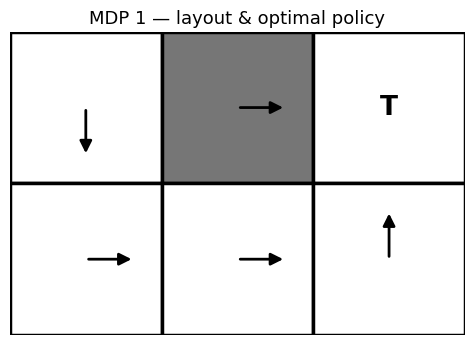

Saved: gbec_outputs/mdp1_layout.pdf


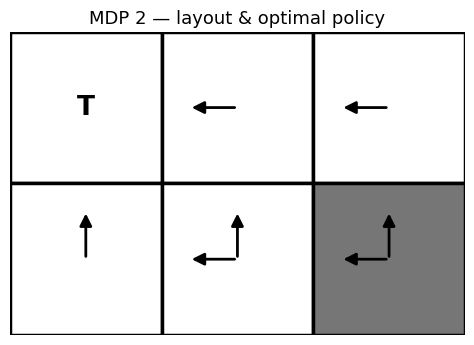

Saved: gbec_outputs/mdp2_layout.pdf


In [6]:
os.makedirs("gbec_outputs", exist_ok=True)

for name, env, q, fname in [
    ("MDP 1 — layout & optimal policy", env1, q1, "gbec_outputs/mdp1_layout.pdf"),
    ("MDP 2 — layout & optimal policy", env2, q2, "gbec_outputs/mdp2_layout.pdf"),
]:
    fig, ax = plt.subplots(figsize=(5, 3.5))
    draw_mdp_layout(ax, env, q, name)
    plt.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

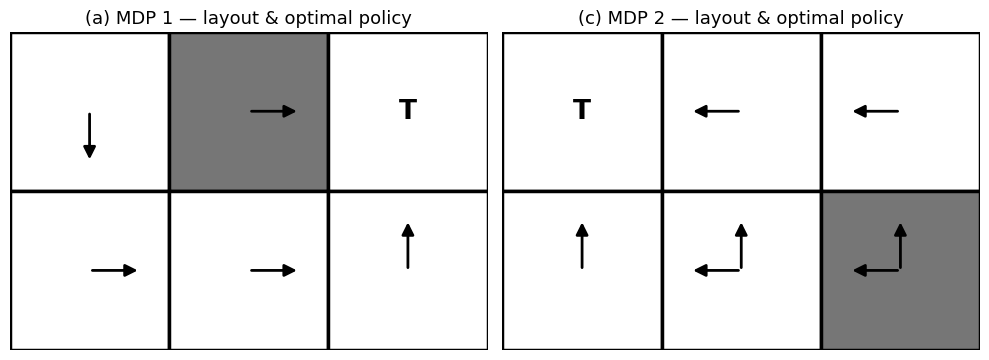

Saved: gbec_outputs/mdp_layouts_comparison.pdf


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

draw_mdp_layout(ax1, env1, q1, "(a) MDP 1 — layout & optimal policy")
draw_mdp_layout(ax2, env2, q2, "(c) MDP 2 — layout & optimal policy")

plt.tight_layout()

out = "gbec_outputs/mdp_layouts_comparison.pdf"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Step 2 — Action-successor features ψ(s, a)

ψ(s, a) is the expected discounted feature sum when taking action *a* at state *s*  
then following the optimal policy.  These encode the full long-run feature consequence  
of each action choice, accounting for stochastic transitions and future states.

In [8]:
# Suppress the informational print inside compute_successor_features_iterative_from_q
with redirect_stdout(io.StringIO()):
    mu_sa1, _, _, _ = compute_successor_features_iterative_from_q(env1, q1)
    mu_sa2, _, _, _ = compute_successor_features_iterative_from_q(env2, q2)

print("ψ(s,a) shape:", mu_sa1.shape, "  (S, A, d)")

for name, env, q, mu_sa in [
    ("MDP 1", env1, q1, mu_sa1),
    ("MDP 2", env2, q2, mu_sa2),
]:
    print(f"\n{name} — ψ(s,a):")
    for s in range(env.get_num_states()):
        if s in env.terminal_states:
            continue
        for a in range(env.get_num_actions()):
            is_opt = abs(q[s, a] - np.max(q[s])) < 1e-10
            tag = " *" if is_opt else ""
            print(f"  s{s}, {ACTION_NAMES[a]:5s}{tag}: ψ={np.round(mu_sa[s, a], 4)}")

ψ(s,a) shape: (6, 4, 2)   (S, A, d)

MDP 1 — ψ(s,a):
  s0, UP   : ψ=[0.    4.901]
  s0, DOWN  *: ψ=[0.     3.9404]
  s0, LEFT : ψ=[0.    4.901]
  s0, RIGHT: ψ=[1.   0.99]
  s1, UP   : ψ=[1.   0.99]
  s1, DOWN : ψ=[0.     2.9701]
  s1, LEFT : ψ=[0.    4.901]
  s1, RIGHT *: ψ=[0. 1.]
  s3, UP   : ψ=[0.    4.901]
  s3, DOWN : ψ=[0.     3.9404]
  s3, LEFT : ψ=[0.     3.9404]
  s3, RIGHT *: ψ=[0.     2.9701]
  s4, UP   : ψ=[1.   0.99]
  s4, DOWN : ψ=[0.     2.9701]
  s4, LEFT : ψ=[0.     3.9404]
  s4, RIGHT *: ψ=[0.   1.99]
  s5, UP    *: ψ=[0. 1.]
  s5, DOWN : ψ=[0.   1.99]
  s5, LEFT : ψ=[0.     2.9701]
  s5, RIGHT: ψ=[0.   1.99]

MDP 2 — ψ(s,a):
  s1, UP   : ψ=[0.   1.99]
  s1, DOWN : ψ=[0.     2.9701]
  s1, LEFT  *: ψ=[0. 1.]
  s1, RIGHT: ψ=[0.     2.9701]
  s2, UP   : ψ=[0.     2.9701]
  s2, DOWN : ψ=[1.     2.9404]
  s2, LEFT  *: ψ=[0.   1.99]
  s2, RIGHT: ψ=[0.     2.9701]
  s3, UP    *: ψ=[0. 1.]
  s3, DOWN : ψ=[0.   1.99]
  s3, LEFT : ψ=[0.   1.99]
  s3, RIGHT: ψ=[0.     2.9701]
  

## Step 3 — Derive constraints from all optimal demonstrations

For every non-terminal state *s*, every optimal action *a** and every non-optimal action *b*:

$$v = \psi(s,a^*) - \psi(s,b), \quad \text{constraint: } v \cdot w \geq 0$$

These constraints are the same as those induced by observing a demonstrator who always  
takes optimal actions — i.e., all possible optimal demonstrations combined.

In [9]:
def get_gbec_constraints(mu_sa, q, env):
    """Return minimal non-redundant constraints for the gBEC from all optimal demonstrations."""
    raw = derive_constraints_from_q_ties(mu_sa, q, env)
    vecs = [v for v, *_ in raw]
    return remove_redundant_constraints(vecs)


vecs1 = get_gbec_constraints(mu_sa1, q1, env1)
vecs2 = get_gbec_constraints(mu_sa2, q2, env2)

for name, vecs in [("MDP 1", vecs1), ("MDP 2", vecs2)]:
    print(f"\n{name}: {len(vecs)} non-redundant constraint(s)")
    for i, v in enumerate(vecs):
        margin = np.dot(v, TRUE_REWARD)
        print(f"  Constraint {i+1}: v = {np.round(v, 6)},  v·w_true = {margin:.6f}")


MDP 1: 2 non-redundant constraint(s)
  Constraint 1: v = [ 0. -1.],  v·w_true = 0.242536
  Constraint 2: v = [-0.321     0.947079],  v·w_true = 0.081716

MDP 2: 2 non-redundant constraint(s)
  Constraint 1: v = [ 0. -1.],  v·w_true = 0.242536
  Constraint 2: v = [-0.999559  0.029688],  v·w_true = 0.962515


## Sanity check — true reward is in both feasible regions

In [10]:
for name, vecs in [("MDP 1", vecs1), ("MDP 2", vecs2)]:
    ok = all(np.dot(v, TRUE_REWARD) >= -1e-10 for v in vecs)
    print(f"{name}: true reward satisfies all constraints → {ok}")

MDP 1: true reward satisfies all constraints → True
MDP 2: true reward satisfies all constraints → True


## Plotting helpers

In [11]:
def _feasible_polygon(vecs, box=1.0, tol=1e-12):
    """Vertices of { w : v_i · w ≥ 0 } ∩ [-box,box]², ordered CCW."""
    vecs = np.asarray(vecs, float).reshape(-1, 2)
    # halfspace: a·x + b·y + c ≤ 0  ←→  v·w ≥ 0 rewritten as (-vx)·x + (-vy)·y ≤ 0
    half = [(-vx, -vy, 0.0) for vx, vy in vecs]
    half += [(1, 0, -box), (-1, 0, -box), (0, 1, -box), (0, -1, -box)]

    pts = []
    m = len(half)
    for i in range(m):
        a1, b1, c1 = half[i]
        for j in range(i + 1, m):
            a2, b2, c2 = half[j]
            D = a1 * b2 - a2 * b1
            if abs(D) < tol:
                continue
            x = (b1 * c2 - b2 * c1) / D
            y = (c1 * a2 - c2 * a1) / D
            if all(a * x + b * y + c <= tol for a, b, c in half):
                pts.append((x, y))

    if not pts:
        return np.empty((0, 2))
    pts = np.unique(np.round(pts, 12), axis=0)
    cen = pts.mean(0)
    return pts[np.argsort(np.arctan2(pts[:, 1] - cen[1], pts[:, 0] - cen[0]))]


CONSTRAINT_COLORS = ["#d81b60", "#008080", "#1f77b4", "#ff7f0e"]

def plot_gbec(ax, vecs, title, true_reward=None, box=1.0, fontsize=11):
    """Draw constraint lines and feasible polygon on *ax*."""
    xs = np.linspace(-box, box, 600)
    handles = []

    for i, (vx, vy) in enumerate(vecs):
        col = CONSTRAINT_COLORS[i % len(CONSTRAINT_COLORS)]
        if abs(vy) < 1e-12:
            h = ax.axvline(0, color=col, lw=4, label=f"Constraint {i + 1}")
        else:
            (h,) = ax.plot(xs, -(vx / vy) * xs, color=col, lw=4,
                           label=f"Constraint {i + 1}")
        handles.append(h)

    poly = _feasible_polygon(vecs, box=box)
    if poly.shape[0] > 0:
        ax.add_patch(Polygon(poly, closed=True, facecolor="#f5bd23",
                             alpha=0.9, edgecolor="none", hatch="///"))

    if true_reward is not None:
        ax.plot(*true_reward, marker="*", color="k", ms=12, zorder=5,
                label="True Reward")

    ax.axhline(0, color="k", lw=1)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlim(-box, box)
    ax.set_ylim(-box, box)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("w1", fontsize=fontsize)
    ax.set_ylabel("w2", fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1)
    ax.legend(fontsize=fontsize - 1, loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.3)


print("Plotting helpers ready.")

Plotting helpers ready.


## Individual plots

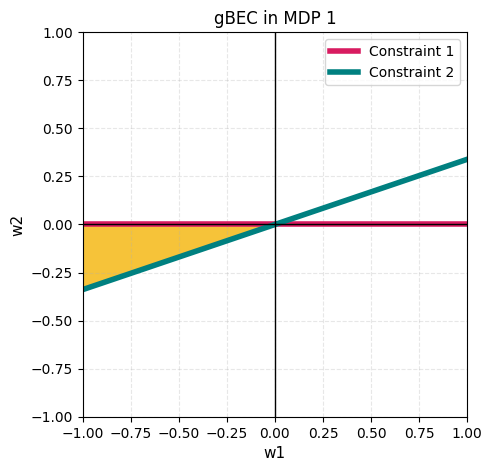

Saved: gbec_outputs/gbec_mdp1.pdf


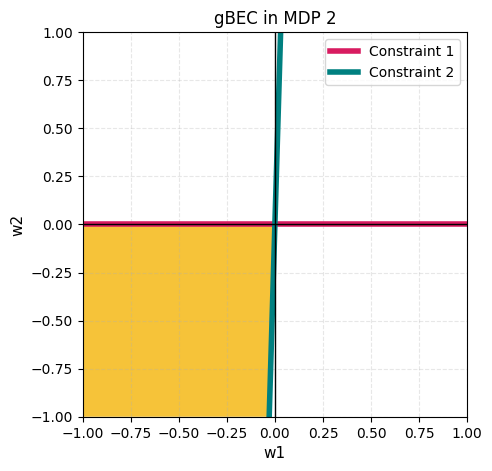

Saved: gbec_outputs/gbec_mdp2.pdf


In [12]:
os.makedirs("gbec_outputs", exist_ok=True)

for name, vecs, fname in [
    ("gBEC in MDP 1", vecs1, "gbec_outputs/gbec_mdp1.pdf"),
    ("gBEC in MDP 2", vecs2, "gbec_outputs/gbec_mdp2.pdf"),
]:
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_gbec(ax, vecs, name)
    plt.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## Side-by-side comparison — Figure 4 style

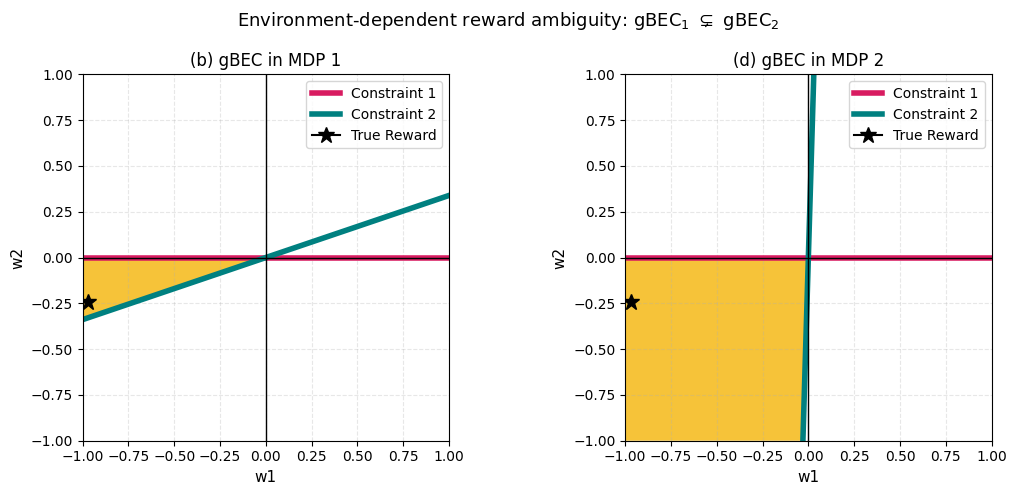

Saved: gbec_outputs/gbec_comparison.pdf


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

plot_gbec(ax1, vecs1, "(b) gBEC in MDP 1", true_reward=TRUE_REWARD)
plot_gbec(ax2, vecs2, "(d) gBEC in MDP 2", true_reward=TRUE_REWARD)

fig.suptitle(
    r"Environment-dependent reward ambiguity: "
    r"gBEC$_1$ $\subsetneq$ gBEC$_2$",
    fontsize=13,
)
plt.tight_layout()

out = "gbec_outputs/gbec_comparison.pdf"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Summary

| | MDP 1 | MDP 2 |
|---|---|---|
| Grey cells | 1 (top-left) | 3 (top-left + bottom row) |
| Non-redundant constraints | len(vecs1) | len(vecs2) |
| Feasible region | smaller | larger |

The larger grey coverage in MDP 2 makes optimal trajectories less distinguishable  
in feature space, producing weaker constraints and a strictly larger gBEC.

In [14]:
def gbec_area(vecs, box=1.0, res=400):
    """Fraction of the [-box,box]² square that is feasible."""
    xs = np.linspace(-box, box, res)
    W1, W2 = np.meshgrid(xs, xs)
    feasible = np.ones_like(W1, dtype=bool)
    for v in vecs:
        feasible &= v[0] * W1 + v[1] * W2 >= 0
    return feasible.mean()


a1 = gbec_area(vecs1)
a2 = gbec_area(vecs2)
print(f"gBEC area (fraction of square):")
print(f"  MDP 1: {a1:.4f}")
print(f"  MDP 2: {a2:.4f}")
print(f"  gBEC1 ⊊ gBEC2: {a1 < a2}")


gBEC area (fraction of square):
  MDP 1: 0.0424
  MDP 2: 0.2463
  gBEC1 ⊊ gBEC2: True
